# EDA — Módulo 2: Detección de distracciones al conducir (imágenes)

Análisis exploratorio del dataset **Multi-Class Driver Behavior Image Dataset**, usado para entrenar el clasificador por transfer learning del módulo 2 (detección de conducción distraída).

- **Ubicación:** `data/raw/module2_distraction/Multi-Class Driver Behavior Image Dataset/`
- **Organización:** una carpeta por clase, **sin split train/test predefinido** (el pipeline de entrenamiento crea sus propios splits estratificados).
- **Clases esperadas:** `other_activities`, `safe_driving`, `talking_phone`, `texting_phone`, `turning`.

Contenido del análisis: conteo por clase, distribución de resoluciones, estadísticas de brillo/contraste, ejemplos visuales y exportación de figuras + resumen JSON a `docs/figures/module2_distraction/`.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

%matplotlib inline
sns.set_theme(style="whitegrid")

# Rutas relativas a la raiz del repo (el notebook vive en notebooks/)
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR
DATA_DIR = REPO_ROOT / "data" / "raw" / "module2_distraction" / "Multi-Class Driver Behavior Image Dataset"
FIG_DIR = REPO_ROOT / "docs" / "figures" / "module2_distraction"
FIG_DIR.mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg", ".jpeg", ".png"}
CLASSES = sorted(d.name for d in DATA_DIR.iterdir() if d.is_dir())

print("Raiz del repo:", REPO_ROOT)
print("Directorio de datos:", DATA_DIR)
print("Clases encontradas:", CLASSES)

Raiz del repo: D:\UNAL\2026-1S\Redes Neuronales y Alg. Bio\rna-sistema_de_transporte_inteligente
Directorio de datos: D:\UNAL\2026-1S\Redes Neuronales y Alg. Bio\rna-sistema_de_transporte_inteligente\data\raw\module2_distraction\Multi-Class Driver Behavior Image Dataset
Clases encontradas: ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']


## 1. Conteo de imágenes por clase

Contamos los archivos de imagen en cada carpeta-clase. Como el dataset **no trae split train/test**, todas las imágenes pertenecen a un único conjunto; el split se hace después en el pipeline de entrenamiento (`src/module2_distraction/`).

In [2]:
registros = []
for clase in CLASSES:
    archivos = [p for p in (DATA_DIR / clase).iterdir() if p.suffix.lower() in IMG_EXTS]
    registros.append({"clase": clase, "split": "unico (sin train/test)", "n_imagenes": len(archivos)})

conteo = pd.DataFrame(registros)
total_imagenes = int(conteo["n_imagenes"].sum())
conteo["porcentaje"] = (conteo["n_imagenes"] / total_imagenes * 100).round(2)

print(f"Total de imagenes: {total_imagenes}")
print(f"Ratio clase mayoritaria / minoritaria: {conteo['n_imagenes'].max() / conteo['n_imagenes'].min():.2f}")
conteo

Total de imagenes: 7276
Ratio clase mayoritaria / minoritaria: 1.42


,clase,split,n_imagenes,porcentaje
0,other_activities,unico (sin train/test),1184,16.27
1,safe_driving,unico (sin train/test),1679,23.08
2,talking_phone,unico (sin train/test),1513,20.79
3,texting_phone,unico (sin train/test),1561,21.45
4,turning,unico (sin train/test),1339,18.40


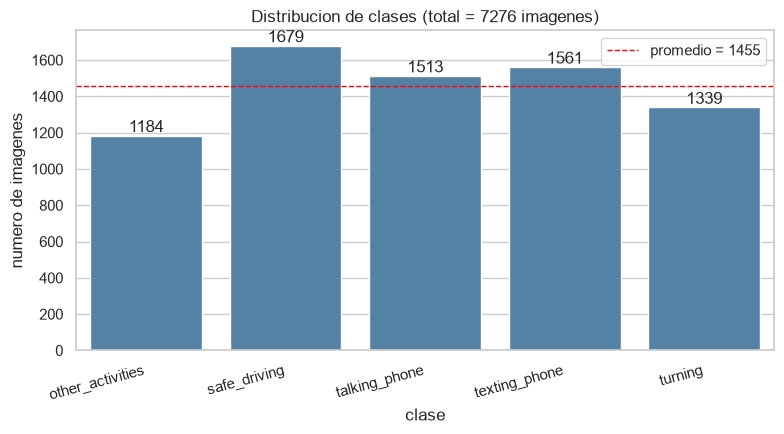

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=conteo, x="clase", y="n_imagenes", color="steelblue", ax=ax)
ax.bar_label(ax.containers[0])
ax.axhline(total_imagenes / len(CLASSES), color="red", linestyle="--", linewidth=1,
           label=f"promedio = {total_imagenes / len(CLASSES):.0f}")
ax.set_title(f"Distribucion de clases (total = {total_imagenes} imagenes)")
ax.set_xlabel("clase")
ax.set_ylabel("numero de imagenes")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "distribucion_clases.png", dpi=150)
plt.show()

In [4]:
# Formatos de archivo presentes en el dataset
ext_por_clase = {}
for clase in CLASSES:
    exts = {}
    for p in (DATA_DIR / clase).iterdir():
        if p.suffix.lower() in IMG_EXTS:
            exts[p.suffix.lower()] = exts.get(p.suffix.lower(), 0) + 1
    ext_por_clase[clase] = exts

df_ext = pd.DataFrame(ext_por_clase).fillna(0).astype(int).T
df_ext["total"] = df_ext.sum(axis=1)
df_ext

,.png,.jpg,total
other_activities,65,1119,1184
safe_driving,35,1644,1679
talking_phone,24,1489,1513
texting_phone,14,1547,1561
turning,62,1277,1339


## 2. Distribución de resoluciones

Las resoluciones nativas importan porque el pipeline hace *resize* a 224×224. Tomamos una **muestra aleatoria reproducible de 150 imágenes por clase** (`seed = 42`) y registramos ancho y alto de cada una.

In [5]:
MUESTRA_POR_CLASE = 150
rng = random.Random(42)

muestra = []
for clase in CLASSES:
    archivos = sorted(p for p in (DATA_DIR / clase).iterdir() if p.suffix.lower() in IMG_EXTS)
    elegidos = rng.sample(archivos, min(MUESTRA_POR_CLASE, len(archivos)))
    for ruta in elegidos:
        with Image.open(ruta) as im:
            ancho, alto = im.size
        muestra.append({"clase": clase, "ruta": ruta, "ancho": ancho, "alto": alto})

df_muestra = pd.DataFrame(muestra)
resumen_res = (
    df_muestra.groupby(["ancho", "alto"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)
resumen_res["porcentaje_muestra"] = (resumen_res["n"] / len(df_muestra) * 100).round(2)

print(f"Tamano de la muestra: {len(df_muestra)} imagenes")
print(f"Resoluciones distintas en la muestra: {len(resumen_res)}")
print(f"Ancho: min={df_muestra['ancho'].min()} px, max={df_muestra['ancho'].max()} px")
print(f"Alto:  min={df_muestra['alto'].min()} px, max={df_muestra['alto'].max()} px")
resumen_res.head(10)

Tamano de la muestra: 750 imagenes
Resoluciones distintas en la muestra: 9
Ancho: min=623 px, max=4096 px
Alto:  min=384 px, max=4096 px


,ancho,alto,n,porcentaje_muestra
0,640,480,675,90.00
1,683,384,23,3.07
2,3072,4096,19,2.53
3,4096,3072,15,2.00
4,2460,3280,13,1.73
5,4032,3024,2,0.27
6,623,842,1,0.13
7,2395,2938,1,0.13
8,2371,3310,1,0.13


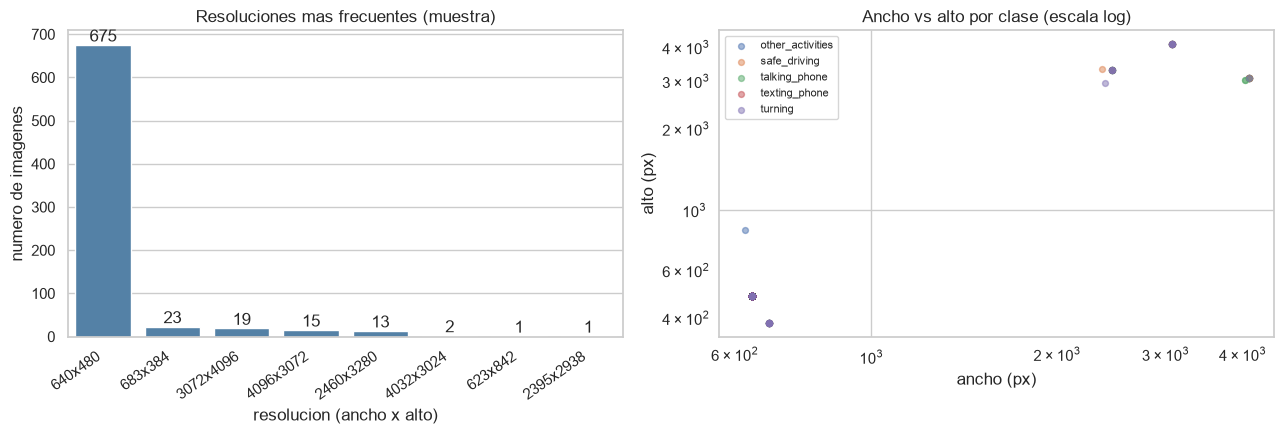

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

top_res = resumen_res.head(8).copy()
top_res["resolucion"] = top_res["ancho"].astype(str) + "x" + top_res["alto"].astype(str)
sns.barplot(data=top_res, x="resolucion", y="n", color="steelblue", ax=axes[0])
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title("Resoluciones mas frecuentes (muestra)")
axes[0].set_xlabel("resolucion (ancho x alto)")
axes[0].set_ylabel("numero de imagenes")
plt.setp(axes[0].get_xticklabels(), rotation=35, ha="right")

for clase in CLASSES:
    sub = df_muestra[df_muestra["clase"] == clase]
    axes[1].scatter(sub["ancho"], sub["alto"], alpha=0.5, s=18, label=clase)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Ancho vs alto por clase (escala log)")
axes[1].set_xlabel("ancho (px)")
axes[1].set_ylabel("alto (px)")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "distribucion_resoluciones.png", dpi=150)
plt.show()

## 3. Brillo y contraste por clase

Sobre la **misma muestra** calculamos, para cada imagen (convertida a RGB):

- **Brillo:** media de los valores de píxel (escala 0–255).
- **Contraste:** desviación estándar de los valores de píxel.

Si alguna clase tuviera un brillo sistemáticamente distinto (p. ej. fotos nocturnas), el modelo podría aprender ese atajo en lugar de la señal visual relevante.

In [7]:
stats = []
for fila in muestra:
    with Image.open(fila["ruta"]) as im:
        arr = np.asarray(im.convert("RGB"), dtype=np.float32)
    stats.append({"clase": fila["clase"], "brillo": float(arr.mean()), "contraste": float(arr.std())})

df_stats = pd.DataFrame(stats)
resumen_brillo = (
    df_stats.groupby("clase")
    .agg(
        brillo_media=("brillo", "mean"),
        brillo_std=("brillo", "std"),
        contraste_medio=("contraste", "mean"),
        contraste_std=("contraste", "std"),
    )
    .round(2)
)
resumen_brillo

,brillo_media,brillo_std,contraste_medio,contraste_std
clase,,,,
other_activities,97.98,16.20,78.83,9.01
safe_driving,92.91,12.39,79.53,9.09
talking_phone,94.61,13.63,80.13,7.50
texting_phone,91.35,11.67,80.25,6.06
turning,94.51,13.80,80.18,7.48


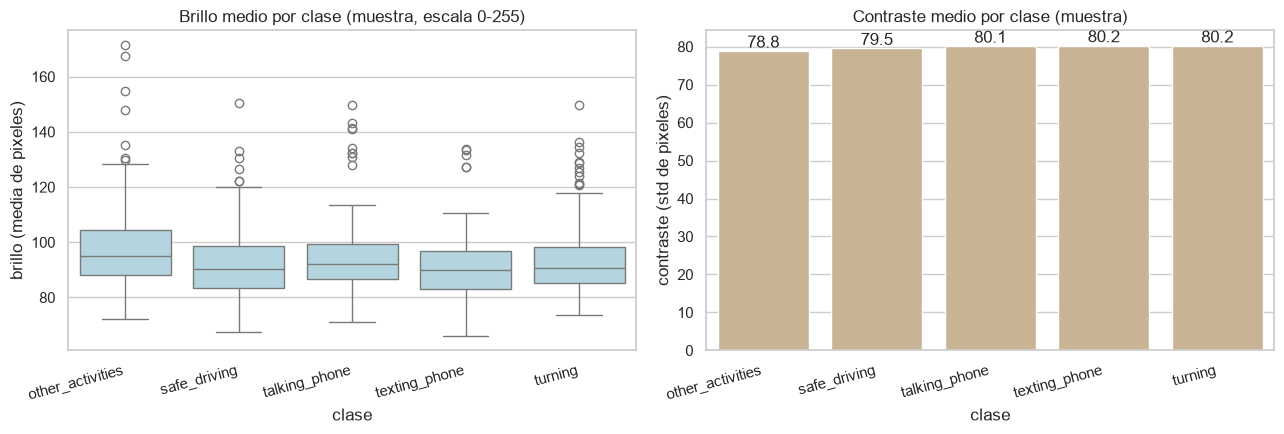

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df_stats, x="clase", y="brillo", color="lightblue", ax=axes[0])
axes[0].set_title("Brillo medio por clase (muestra, escala 0-255)")
axes[0].set_xlabel("clase")
axes[0].set_ylabel("brillo (media de pixeles)")
plt.setp(axes[0].get_xticklabels(), rotation=15, ha="right")

sns.barplot(data=resumen_brillo.reset_index(), x="clase", y="contraste_medio", color="tan", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt="%.1f")
axes[1].set_title("Contraste medio por clase (muestra)")
axes[1].set_xlabel("clase")
axes[1].set_ylabel("contraste (std de pixeles)")
plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right")

fig.tight_layout()
fig.savefig(FIG_DIR / "brillo_por_clase.png", dpi=150)
plt.show()

## 4. Ejemplos visuales por clase

Grid con 4 ejemplos aleatorios por clase (`seed = 7`). Sirve para verificar cualitativamente que las etiquetas son coherentes y que hay variabilidad de fondos, ángulos y sujetos dentro de cada clase.

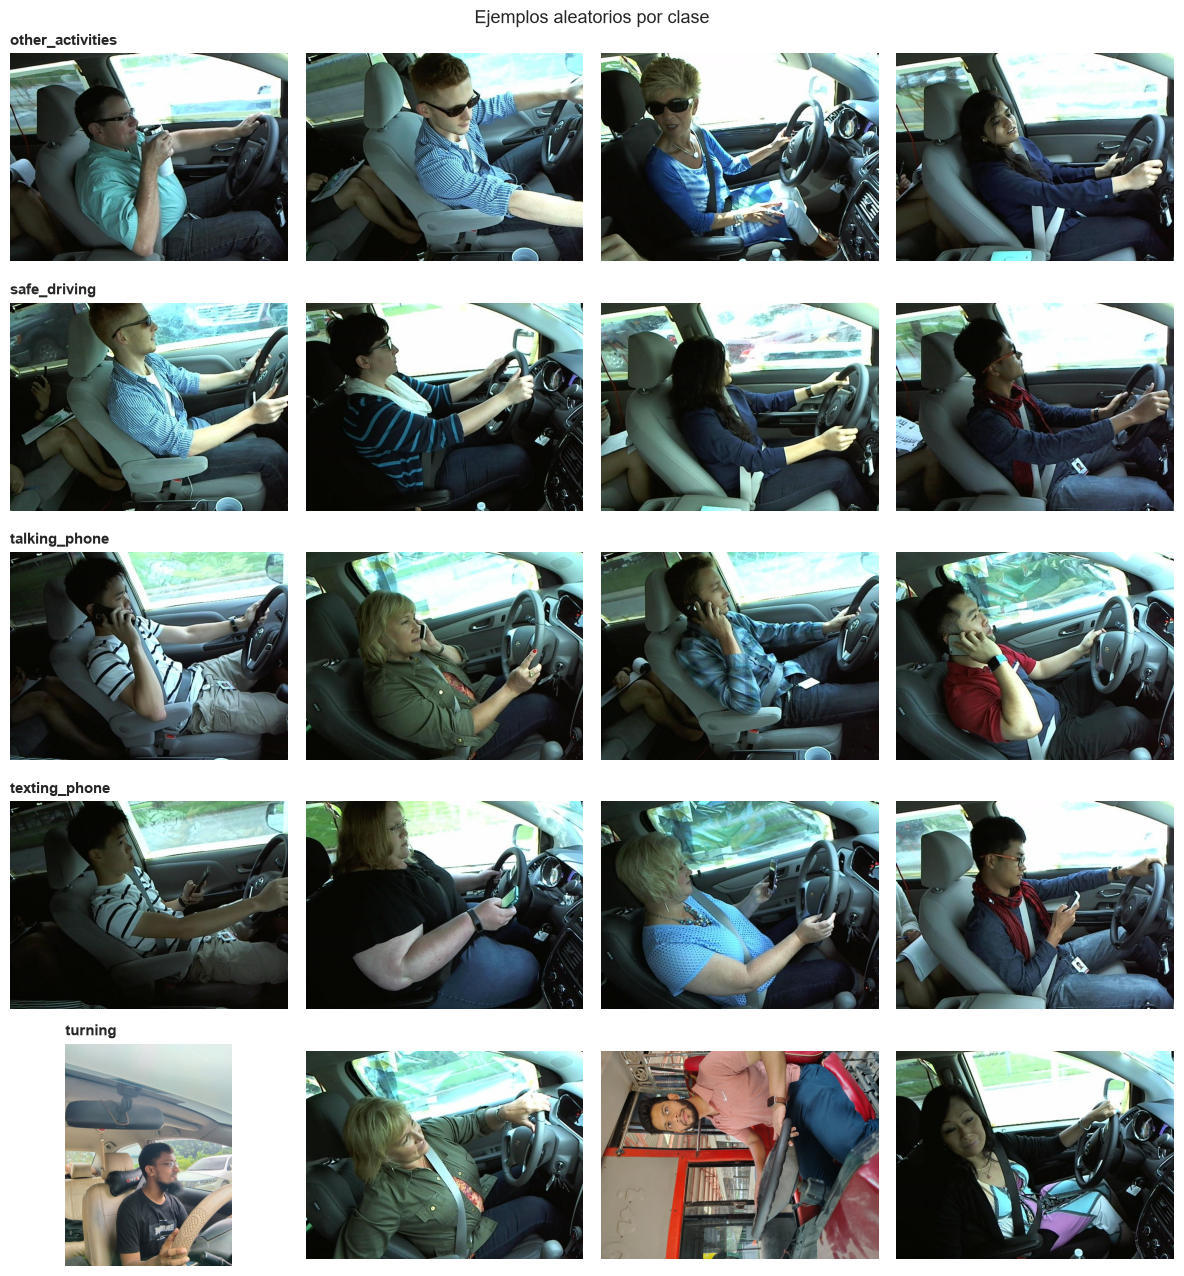

In [9]:
N_EJEMPLOS = 4
rng_img = random.Random(7)

fig, axes = plt.subplots(len(CLASSES), N_EJEMPLOS, figsize=(12, 2.6 * len(CLASSES)))
for i, clase in enumerate(CLASSES):
    archivos = sorted(p for p in (DATA_DIR / clase).iterdir() if p.suffix.lower() in IMG_EXTS)
    for j, ruta in enumerate(rng_img.sample(archivos, N_EJEMPLOS)):
        with Image.open(ruta) as im:
            axes[i, j].imshow(im)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(clase, loc="left", fontsize=11, fontweight="bold")

fig.suptitle("Ejemplos aleatorios por clase", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "ejemplos_por_clase.png", dpi=150)
plt.show()

## 5. Resumen exportable

Guardamos los números clave del EDA en `docs/figures/module2_distraction/eda_summary.json` para trazabilidad.

In [10]:
res_dom = resumen_res.iloc[0]
summary = {
    "dataset": "Multi-Class Driver Behavior Image Dataset",
    "ruta_datos": "data/raw/module2_distraction/Multi-Class Driver Behavior Image Dataset",
    "total_imagenes": total_imagenes,
    "conteo_por_clase": {r.clase: int(r.n_imagenes) for r in conteo.itertuples()},
    "porcentaje_por_clase": {r.clase: float(r.porcentaje) for r in conteo.itertuples()},
    "split": "sin split train/test predefinido (carpetas planas por clase)",
    "extensiones": {k: int(v) for k, v in df_ext.sum().drop("total").items()},
    "muestra": {"n": int(len(df_muestra)), "por_clase": MUESTRA_POR_CLASE, "seed": 42},
    "resolucion_dominante": {
        "resolucion": f"{int(res_dom['ancho'])}x{int(res_dom['alto'])}",
        "n_en_muestra": int(res_dom["n"]),
        "porcentaje_muestra": float(res_dom["porcentaje_muestra"]),
    },
    "n_resoluciones_distintas_muestra": int(len(resumen_res)),
    "ancho_px": {"min": int(df_muestra["ancho"].min()), "max": int(df_muestra["ancho"].max()),
                 "media": round(float(df_muestra["ancho"].mean()), 1)},
    "alto_px": {"min": int(df_muestra["alto"].min()), "max": int(df_muestra["alto"].max()),
                "media": round(float(df_muestra["alto"].mean()), 1)},
    "brillo_medio_por_clase": {k: float(v) for k, v in resumen_brillo["brillo_media"].items()},
    "contraste_medio_por_clase": {k: float(v) for k, v in resumen_brillo["contraste_medio"].items()},
    "figuras": [
        "distribucion_clases.png",
        "distribucion_resoluciones.png",
        "brillo_por_clase.png",
        "ejemplos_por_clase.png",
    ],
}

ruta_json = FIG_DIR / "eda_summary.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Resumen guardado en: {ruta_json}")
print(json.dumps(summary, indent=2, ensure_ascii=False))

Resumen guardado en: D:\UNAL\2026-1S\Redes Neuronales y Alg. Bio\rna-sistema_de_transporte_inteligente\docs\figures\module2_distraction\eda_summary.json
{
  "dataset": "Multi-Class Driver Behavior Image Dataset",
  "ruta_datos": "data/raw/module2_distraction/Multi-Class Driver Behavior Image Dataset",
  "total_imagenes": 7276,
  "conteo_por_clase": {
    "other_activities": 1184,
    "safe_driving": 1679,
    "talking_phone": 1513,
    "texting_phone": 1561,
    "turning": 1339
  },
  "porcentaje_por_clase": {
    "other_activities": 16.27,
    "safe_driving": 23.08,
    "talking_phone": 20.79,
    "texting_phone": 21.45,
    "turning": 18.4
  },
  "split": "sin split train/test predefinido (carpetas planas por clase)",
  "extensiones": {
    ".png": 200,
    ".jpg": 7076
  },
  "muestra": {
    "n": 750,
    "por_clase": 150,
    "seed": 42
  },
  "resolucion_dominante": {
    "resolucion": "640x480",
    "n_en_muestra": 675,
    "porcentaje_muestra": 90.0
  },
  "n_resoluciones_disti

## Hallazgos principales

1. **Tamaño y balance:** 7.276 imágenes en 5 clases, con desbalance moderado: `safe_driving` es la mayoritaria (1.679, 23,1 %) y `other_activities` la minoritaria (1.184, 16,3 %); la razón máx/mín es ≈ 1,42. No se requieren técnicas agresivas de rebalanceo, pero conviene monitorear el recall por clase.
2. **Sin split predefinido:** el dataset viene como carpetas planas por clase; el split estratificado train/val/test lo crea el pipeline de entrenamiento.
3. **Formatos:** 7.076 JPG y 200 PNG (capturas de pantalla, concentradas en `other_activities` (65) y `turning` (62)).
4. **Resoluciones:** la resolución dominante es **640×480 (≈ 90 % de la muestra)**; hay una cola pequeña de imágenes de alta resolución (hasta ~4.100 px por lado (p. ej. 3072×4096 y 4096×3072)). El *resize* uniforme a 224×224 del pipeline es adecuado y no destruye información relevante.
5. **Brillo/contraste homogéneos entre clases:** el brillo medio por clase está entre ≈ 91 y ≈ 98 (escala 0–255) y el contraste medio ≈ 79–80 en todas. La iluminación no es un atajo discriminatorio: las clases difieren en contenido, no en exposición.
6. **Variabilidad intra-clase:** los ejemplos muestran diversidad de sujetos, ángulos y fondos dentro de cada clase, lo que favorece la generalización del modelo por transfer learning.